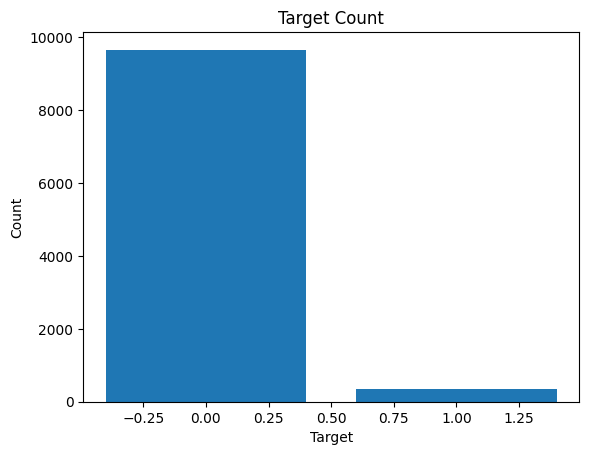

In [ ]:
import pandas as pd
import sklearn.preprocessing as pp
from matplotlib import pyplot as plt
from imblearn.over_sampling import SMOTE #synthetic minority oversampling technique

data = pd.read_csv('predictive_maintenance.csv')

data['Type']= pp.LabelEncoder().fit_transform(data['Type'])
dataSelected = data.iloc[:,2:-1]

plt.bar(dataSelected.groupby('Target').count().index,dataSelected.groupby('Target').count()['Type'])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Count')
plt.show()

# média, desvio padrão
# Media_classe_1, Desvio_classe_1 / minoritária / N(Media_classe_1, Desvio_classe_1)
# Media_classe_0, Desvio_classe_0

dataFailures = dataSelected[dataSelected['Target']==1]

dataNoFailures = dataSelected[dataSelected['Target']==0]






**Descrição dos dados**

In [ ]:
dataFailures.describe()



,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,339.000000,339.000000,339.000000,339.000000,339.000000,339.000000,339.0
mean,1.182891,300.886431,310.290265,1496.486726,50.168142,143.781711,1.0
std,0.523588,2.071473,1.363686,384.943547,16.374498,72.759876,0.0
min,0.000000,295.600000,306.100000,1181.000000,3.800000,0.000000,1.0
25%,1.000000,299.100000,309.500000,1326.500000,45.950000,84.500000,1.0
50%,1.000000,301.600000,310.400000,1365.000000,53.700000,165.000000,1.0
75%,1.000000,302.500000,311.200000,1421.500000,61.200000,207.500000,1.0
max,2.000000,304.400000,313.700000,2886.000000,76.600000,253.000000,1.0


In [ ]:
dataNoFailures.describe()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,9661.000000,9661.000000,9661.000000,9661.000000,9661.000000,9661.000000,9661.0
mean,1.199979,299.973999,309.995570,1540.260014,39.629655,106.693717,0.0
std,0.602758,1.990748,1.486846,167.394734,9.472080,62.945790,0.0
min,0.000000,295.300000,305.700000,1168.000000,12.600000,0.000000,0.0
25%,1.000000,298.300000,308.800000,1429.000000,33.100000,52.000000,0.0
50%,1.000000,300.000000,310.000000,1507.000000,39.900000,107.000000,0.0
75%,2.000000,301.500000,311.100000,1615.000000,46.300000,160.000000,0.0
max,2.000000,304.500000,313.800000,2695.000000,70.000000,246.000000,0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC #support vector machine para classificação
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
import sklearn.preprocessing as pp
from matplotlib import pyplot as plt
data = pd.read_csv('predictive_maintenance.csv')

data['Type']= pp.LabelEncoder().fit_transform(data['Type'])
dataSelected = data.iloc[:,2:-1]

X=dataSelected.iloc[:,:-1]
y=dataSelected.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    stratify=y,
                                                    test_size=0.25)




mlp = MLPClassifier()
parameters = {'solver':['sgd'], 'hidden_layer_sizes':[(10,),(20,),(30,),(40,)],'activation':['relu','logistic','tanh']}
my_mlp = GridSearchCV(mlp, parameters)
my_mlp.fit(X_train, y_train)

predictedmlp = my_mlp.predict(X_test)





parameters = {'kernel':['rbf'], 'C':[0.01,0.1,1, 10],'gamma':[0.1,0.01,0.001]}
svc = SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(X_train, y_train)

predictedsvm = clf.predict(X_test)

my_results = pd.DataFrame({})
my_results['Y']=y_test
my_results['SVM']=predictedsvm
my_results['MLP']=predictedmlp
my_results.to_excel('results_mlp_svm.xlsx')
#accuracy_score(y_test,predicted)


In [ ]:
clf


GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'gamma': [0.1, 0.01, 0.001],
                         'kernel': ['rbf']})

In [ ]:
X_train

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
3782,1,302.2,310.8,1827,2025-08-23 00:00:00,9
8203,2,299.4,310.9,1473,40.1,7
8527,1,298.4,309.3,1531,37.4,16
8416,2,298.8,310.1,1585,2025-03-31 00:00:00,147
7363,1,299.5,310.0,1412,48.9,56
...,...,...,...,...,...,...
2555,1,299.3,309.2,1511,37.2,129
6744,2,301.7,311.0,1298,58.1,168
7759,1,300.4,311.8,1272,59.2,198
9231,1,298.2,309.1,1539,36.5,134


In [ ]:
data

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,1,298.2,308.7,1408,40,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,2,298.8,308.4,1604,2025-05-29 00:00:00,14,0,No Failure
9996,9997,H39410,0,298.9,308.4,1632,2025-08-31 00:00:00,17,0,No Failure
9997,9998,M24857,2,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,0,299.0,308.7,1408,48.5,25,0,No Failure


In [ ]:
my_results.to_excel('results_mlp_svm.xlsx')

In [ ]:
from imblearn.over_sampling import  SMOTE # N_1(média,desv),N_2(Média,Desv)...,N_n(Média,desvio)
from matplotlib import pyplot as plt

smote = SMOTE(random_state=10)
X_train_smote, y_train_smote= smote.fit_resample(X_train, y_train) # gerar sinteticamente dados para o treinamento

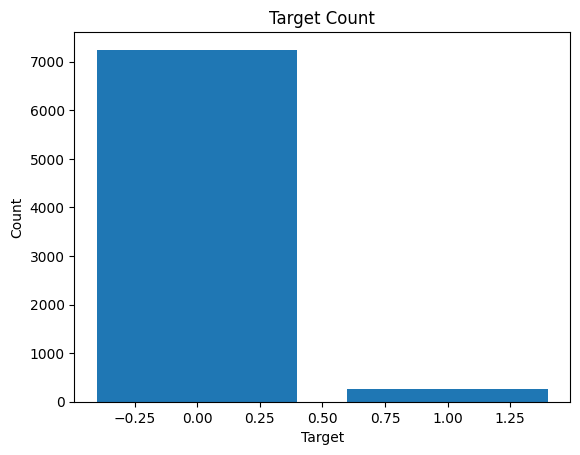

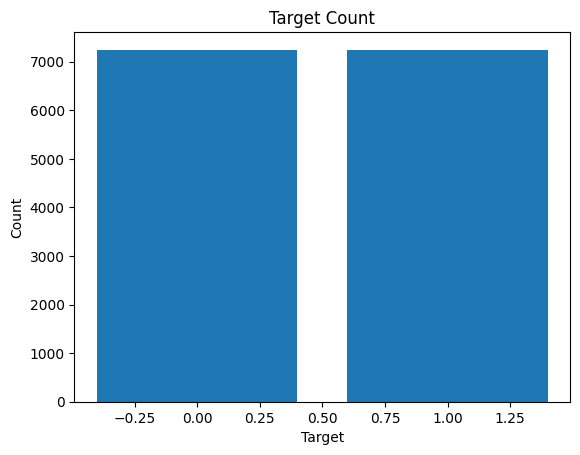

In [ ]:
plt.bar(y_train.groupby(y_train).count().index,y_train.groupby(y_train).count())
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Count')
plt.show()

plt.bar(y_train_smote.groupby(y_train_smote).count().index,y_train_smote.groupby(y_train_smote).count())
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Count')
plt.show()
#

In [ ]:

mlp = MLPClassifier()
parameters = {'solver':['sgd'], 'hidden_layer_sizes':[(10,),(20,),(30,),(40,)],'activation':['relu','logistic','tanh']}
my_mlp = GridSearchCV(mlp, parameters)
my_mlp.fit(X_train_smote, y_train_smote)

predictedmlpsmote = my_mlp.predict(X_test)





parameters = {'kernel':['rbf'], 'C':[0.01,0.1,1, 10],'gamma':[0.1,0.01,0.001]}
svc = SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(X_train_smote, y_train_smote)

predictedsvmsmote = clf.predict(X_test)

my_results['smote_SVM']=predictedsvmsmote
my_results['smote_mlp']=predictedmlpsmote
my_results.to_excel('results_mlp_svm_smote.xlsx')
#accuracy_score(y_test,predicted)

In [ ]:
my_results.head()

metricss=pd.DataFrame({})
metricss['accuracy_mlp']=[accuracy_score(y_test,predictedmlp)]
metricss['accuracy_svm']=[accuracy_score(y_test,predictedsvm)]
metricss['accuracy_svm_smote']=[accuracy_score(y_test,predictedsvmsmote)]
metricss['accuracy_mlp_smote']=[accuracy_score(y_test,predictedmlpsmote)]
metricss.to_excel('metrics.xlsx')


In [ ]:
metricss

,accuracy_mlp,accuracy_svm,accuracy_svm_smote,accuracy_mlp_smote
0,0.966,0.9684,0.9288,0.6444


In [ ]:
import numpy as np
import sklearn.metrics as metrics
metrics.confusion_matrix(y_test,predictedmlpsmote)

array([[2401,   14],
       [  81,    4]])

In [ ]:
metrics.confusion_matrix(y_test,predictedmlp)

array([[2415,    0],
       [  85,    0]])

In [ ]:
metrics.confusion_matrix(y_test,predictedsvm)

array([[2411,    4],
       [  68,   17]])

In [ ]:
metrics.confusion_matrix(y_test,predictedsvmsmote)

array([[2312,  103],
       [  50,   35]])